**Project title: HRV Analysis associated with physiological elements**

**Summary:** 수면, 심박수, 운동 데이터 기반으로 HRV(심박변이도)에 영향을 미치는 요인 분석

**🏃Exercise Analysis - 1
: 운동이 HRV 변화에 미치는 영향 분석 (25.01.15~25.03.07_운동 X)**


📊 [운동 여부별 다음날 HRV 평균]
운동 여부
0    43.05
1    35.71
Name: 다음날 HRV, dtype: float64

📊 [운동량 그룹별 다음날 HRV 평균]
운동량 그룹
낮음       46.29
중간       40.85
높음       36.42
매우 높음    36.32
Name: 다음날 HRV, dtype: float64

📊 [운동량 그룹별 HRV 변화량]
운동량 그룹
낮음      -4.18
중간       8.20
높음       0.45
매우 높음   -3.00
Name: 운동 영향, dtype: float64


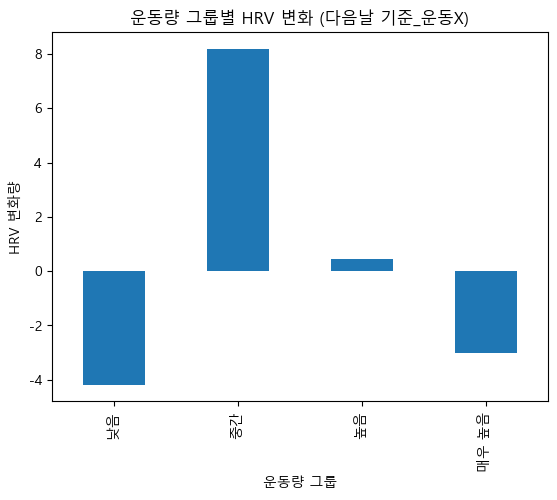

            avg_hr    hrv
날짜                       
2025-01-15   83.10  37.18
2025-01-16   84.10  35.64
2025-01-17   71.29  41.75
2025-01-18   81.95  32.70
2025-01-19   70.48  45.15


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_excel("25.01.15-25.03.07.xlsx")

# 날짜 생성
df['날짜'] = df['날짜/시간'].dt.date

# HRV
daily_hrv = df.groupby('날짜')['심박수 변이성 (밀리초)'].mean().round(2)
daily_count = df.groupby('날짜')['심박수 변이성 (밀리초)'].count()

result = pd.concat([daily_hrv, daily_count], axis=1)
result.columns = ['HRV 평균', 'HRV 측정 횟수']

# 운동 여부
df['운동 여부'] = df['Apple 운동 시간 (분)'] >= 10
result['운동 여부'] = df.groupby('날짜')['운동 여부'].any().astype(int)

# 운동 총 시간
result['운동 총 시간'] = df.groupby('날짜')['Apple 운동 시간 (분)'].sum()

# 다음날 HRV
result['다음날 HRV'] = result['HRV 평균'].shift(-1)

# 운동 영향
result['운동 영향'] = result['다음날 HRV'] - result['HRV 평균']

# 운동량 그룹 (시간 기준)
result['운동량 그룹'] = pd.qcut(
    result['운동 총 시간'],
    q=4,
    labels=['낮음', '중간', '높음', '매우 높음']
)

# 분석 결과
print("\n📊 [운동 여부별 다음날 HRV 평균]")
print(result.groupby('운동 여부')['다음날 HRV'].mean().round(2))

print("\n📊 [운동량 그룹별 다음날 HRV 평균]")
print(result.groupby('운동량 그룹')['다음날 HRV'].mean().round(2))

print("\n📊 [운동량 그룹별 HRV 변화량]")
print(result.groupby('운동량 그룹')['운동 영향'].mean().round(2))

# 그래프 
plt.figure()
result.groupby('운동량 그룹')['운동 영향'].mean().plot(kind='bar')
plt.title('운동량 그룹별 HRV 변화 (다음날 기준_운동X)')
plt.ylabel('HRV 변화량')
plt.show()

# 데이터 확인
print(hr_df.head())


운동이 없는 상태에서는 HRV 전반적으로 감소하는 경향을 보였으며,
특히 낮음 운동량 그룹에서 감소 폭이 크게 나타났다.

반면, 중간 수준의 활동에서는 HRV 증가가 관찰되어
완전한 비활동 상태보다 적당한 움직임이 회복에 긍정적인 영향을 미치는 것으로 해석된다. 

**🏃Exercise Analysis - 2
: 운동이 HRV 변화에 미치는 영향 분석 (25.05.26~25.10.05_운동초기)**


📊 [운동 여부별 다음날 HRV 평균]
운동 여부
0    48.53
1    48.08
Name: 다음날 HRV, dtype: float64

📊 [운동량 그룹별 다음날 HRV 평균]
운동량 그룹
낮음       48.15
중간       50.01
높음       47.55
매우 높음    47.60
Name: 다음날 HRV, dtype: float64

📊 [운동량 그룹별 HRV 변화량]
운동량 그룹
낮음      -1.98
중간       2.19
높음      -1.25
매우 높음    3.67
Name: 운동 영향, dtype: float64


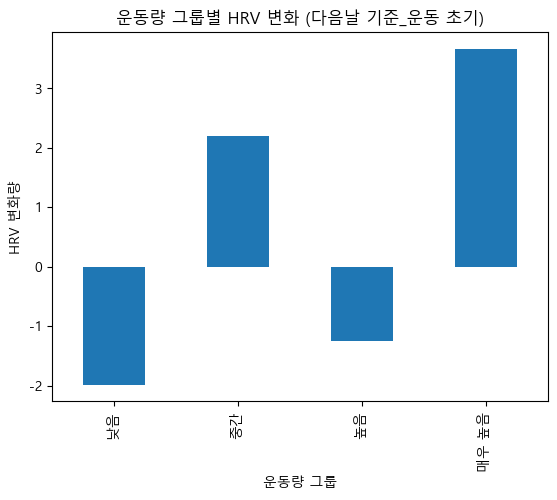

            avg_hr    hrv
날짜                       
2025-01-15   83.10  37.18
2025-01-16   84.10  35.64
2025-01-17   71.29  41.75
2025-01-18   81.95  32.70
2025-01-19   70.48  45.15


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_excel("25.05.26~25.10.05.xlsx")

# 날짜 생성
df['날짜'] = df['날짜/시간'].dt.date

# HRV
daily_hrv = df.groupby('날짜')['심박수 변이성 (밀리초)'].mean().round(2)
daily_count = df.groupby('날짜')['심박수 변이성 (밀리초)'].count()

result = pd.concat([daily_hrv, daily_count], axis=1)
result.columns = ['HRV 평균', 'HRV 측정 횟수']

# 운동 여부
df['운동 여부'] = df['Apple 운동 시간 (분)'] >= 10
result['운동 여부'] = df.groupby('날짜')['운동 여부'].any().astype(int)

# 운동 총 시간
result['운동 총 시간'] = df.groupby('날짜')['Apple 운동 시간 (분)'].sum()

# 다음날 HRV
result['다음날 HRV'] = result['HRV 평균'].shift(-1)

# 운동 영향
result['운동 영향'] = result['다음날 HRV'] - result['HRV 평균']

# 운동량 그룹 (시간 기준)
result['운동량 그룹'] = pd.qcut(
    result['운동 총 시간'],
    q=4,
    labels=['낮음', '중간', '높음', '매우 높음']
)

# 분석 결과
print("\n📊 [운동 여부별 다음날 HRV 평균]")
print(result.groupby('운동 여부')['다음날 HRV'].mean().round(2))

print("\n📊 [운동량 그룹별 다음날 HRV 평균]")
print(result.groupby('운동량 그룹')['다음날 HRV'].mean().round(2))

print("\n📊 [운동량 그룹별 HRV 변화량]")
print(result.groupby('운동량 그룹')['운동 영향'].mean().round(2))

# 그래프 
plt.figure()
result.groupby('운동량 그룹')['운동 영향'].mean().plot(kind='bar')
plt.title('운동량 그룹별 HRV 변화 (다음날 기준_운동 초기)')
plt.ylabel('HRV 변화량')
plt.show()

# 데이터 확인
print(hr_df.head())


운동 초기 단계에서는 HRV 변동성이 크게 나타났으며,
낮은 운동량에서는 감소, 매우 높은 운동량에서는 증가하는 등
운동량에 따른 반응이 불균형하게 나타났다. 

이는 신체가 운동 자극에 아직 적응하지 않은 상태에서
자율신경계 반응이 불안정하게 나타난 결과로 해석된다. 

**🏃Exercise Analysis - 3
: 운동이 HRV 변화에 미치는 영향 분석 (25.12.07~26.04.25_운동중기)**


📊 [운동 여부별 다음날 HRV 평균]
운동 여부
0    46.91
1    45.41
Name: 다음날 HRV, dtype: float64

📊 [운동량 그룹별 다음날 HRV 평균]
운동량 그룹
낮음       47.38
중간       46.97
높음       47.83
매우 높음    42.23
Name: 다음날 HRV, dtype: float64

📊 [운동량 그룹별 HRV 변화량]
운동량 그룹
낮음      -3.77
중간       2.16
높음      -1.78
매우 높음    1.30
Name: 운동 영향, dtype: float64


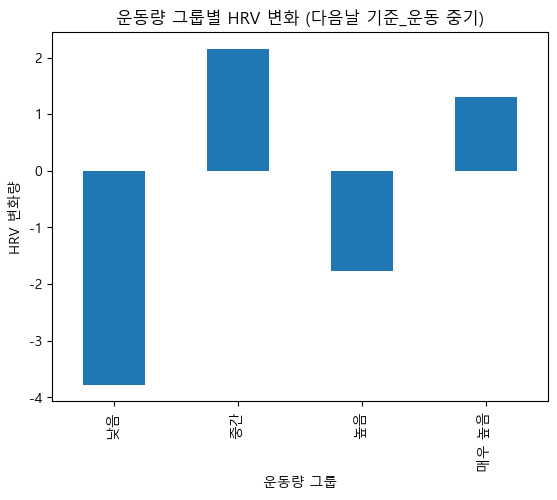

            avg_hr    hrv
날짜                       
2025-01-15   83.10  37.18
2025-01-16   84.10  35.64
2025-01-17   71.29  41.75
2025-01-18   81.95  32.70
2025-01-19   70.48  45.15


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_excel("25.12.07~26.04.25.xlsx")

# 날짜 생성
df['날짜'] = df['날짜/시간'].dt.date

# HRV
daily_hrv = df.groupby('날짜')['심박수 변이성 (밀리초)'].mean().round(2)
daily_count = df.groupby('날짜')['심박수 변이성 (밀리초)'].count()

result = pd.concat([daily_hrv, daily_count], axis=1)
result.columns = ['HRV 평균', 'HRV 측정 횟수']

# 운동 여부
df['운동 여부'] = df['Apple 운동 시간 (분)'] >= 10
result['운동 여부'] = df.groupby('날짜')['운동 여부'].any().astype(int)

# 운동 총 시간
result['운동 총 시간'] = df.groupby('날짜')['Apple 운동 시간 (분)'].sum()

# 다음날 HRV
result['다음날 HRV'] = result['HRV 평균'].shift(-1)

# 운동 영향
result['운동 영향'] = result['다음날 HRV'] - result['HRV 평균']

# 운동량 그룹 (시간 기준)
result['운동량 그룹'] = pd.qcut(
    result['운동 총 시간'],
    q=4,
    labels=['낮음', '중간', '높음', '매우 높음']
)

# 분석 결과
print("\n📊 [운동 여부별 다음날 HRV 평균]")
print(result.groupby('운동 여부')['다음날 HRV'].mean().round(2))

print("\n📊 [운동량 그룹별 다음날 HRV 평균]")
print(result.groupby('운동량 그룹')['다음날 HRV'].mean().round(2))

print("\n📊 [운동량 그룹별 HRV 변화량]")
print(result.groupby('운동량 그룹')['운동 영향'].mean().round(2))

# 그래프 
plt.figure()
result.groupby('운동량 그룹')['운동 영향'].mean().plot(kind='bar')
plt.title('운동량 그룹별 HRV 변화 (다음날 기준_운동 중기)')
plt.ylabel('HRV 변화량')
plt.show()

# 데이터 확인
print(hr_df.head())


지속적인 운동 단계에서는 HRV 변화가 보다 안정적인 패턴을 보였"으며,
중간 운동량에서는 HRV 증가가 유지되었다.

반면, 높은 운동량에서는 피로 누적으로 인해 HRV 감소가 나타났고,
매우 높은 운동량에서는 적응 효과로 인해 다시 HRV 증가가 관찰되었다.

이는 운동과 회복 사이의 균형에 따라 HRV가 비선형적으로 반응함을 시사한다. 

**😴Sleep analysis
: 수면 질 vs HRV, 수면 시간 vs HRV**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 수면 데이터 불러오기
sleep_files = [
    "수면 1 01.15~03.07.xlsx",
    "수면 2 05.26~10.05.xlsx",
    "수면 3 12.07~04.25.xlsx"
]

sleep_df = pd.concat([pd.read_excel(f) for f in sleep_files], ignore_index=True)

# 날짜 생성
sleep_df['날짜'] = pd.to_datetime(sleep_df['Start']).dt.date

# pivot
sleep_pivot = sleep_df.pivot_table(
    index='날짜',
    columns='Value',
    values='Duration (시간)',
    aggfunc='sum'
).fillna(0)

sleep_pivot.columns = sleep_pivot.columns.astype(str)

# 수면 단계 분류
rem = sleep_pivot.get('REM', 0)
core = sleep_pivot.get('코어', sleep_pivot.get('Core', 0))
deep = sleep_pivot.get('깊이', sleep_pivot.get('Deep', 0))
awake = sleep_pivot.get('깨어 있음', sleep_pivot.get('Awake', 0))

# 수면 총 시간 계산
sleep_pivot['sleep_time'] = (rem + core + deep).round(2)
sleep_pivot['total_time'] = sleep_pivot['sleep_time'] + awake

sleep_pivot['sleep_quality'] = (rem + deep) / sleep_pivot['total_time']
sleep_pivot['sleep_quality'] = sleep_pivot['sleep_quality'].replace([np.inf, -np.inf], np.nan)
sleep_pivot.loc[sleep_pivot['sleep_time'] == 0, 'sleep_quality'] = np.nan

# 수면 질 등급
def sleep_quality_label(x):
    if pd.isna(x):
        return None
    elif x < 0.3:
        return '보통'
    elif x < 0.45:
        return '좋음'
    else:
        return '매우 좋음'

sleep_pivot['sleep_quality_label'] = sleep_pivot['sleep_quality'].apply(sleep_quality_label)

# 수면 최종
sleep_final = sleep_pivot.reset_index()
sleep_final['날짜'] = pd.to_datetime(sleep_final['날짜'])


# HRV 데이터 불러오기
all_files = [
    "25.01.15-25.03.07.xlsx",
    "25.05.26~25.10.05.xlsx",
    "25.12.07~26.04.25.xlsx"
]

df_all = pd.concat([pd.read_excel(f) for f in all_files], ignore_index=True)

df_all.columns = df_all.columns.str.strip()


# 날짜 생성
df_all['날짜'] = pd.to_datetime(df_all['날짜/시간']).dt.normalize()



# 하루 평균 HRV
daily_hrv = df_all.groupby('날짜')['심박수 변이성 (밀리초)'].mean().round(2)

# 하루 측정 횟수
daily_count = df_all.groupby('날짜')['심박수 변이성 (밀리초)'].count()

# 합치기
result = pd.concat([daily_hrv, daily_count], axis=1)
result.columns = ['HRV 평균', 'HRV 측정 횟수']

result = result.reset_index()

# 다음날 HRV
result['next_day_hrv'] = result['HRV 평균'].shift(-1)

# merge
df = pd.merge(sleep_final, result, on='날짜', how='inner')

# 분석용 데이터
df_analysis = df[['날짜','sleep_time','sleep_quality','next_day_hrv']].dropna()


# 수면 시간 상관계수 추가
corr = df_analysis['sleep_time'].corr(df_analysis['next_day_hrv'])
print("sleep_time between next_HRV correlation:", corr)

# 수면 질 상관계수 추가
corr = df_analysis['sleep_quality'].corr(df_analysis['next_day_hrv'])
print("sleep_quality between next_HRV correlation:", corr)


# 수면 vs HRV
sns.boxplot(
    x='sleep_quality_label',
    y='next_day_hrv',
    data=df
)

plt.title("Sleep Quality vs Next Day HRV")
plt.show()

# 그래프
sns.regplot(
    x='sleep_time',
    y='next_day_hrv',
    data=df_analysis
)

plt.title("Sleep Time vs Next Day HRV")
plt.xlabel("Sleep Time")
plt.ylabel("Next Day HRV")
plt.show()

# 확인
print(df.head())

수면 시간과 HRV 간에는 뚜렷한 상관관계가 나타나지 않았다.
수면 질과 HRV 간에는 약한 양의 상관관계가 나타났다. (r = 0.12)

**❤️Heart Rate Analysis
심박수(HR)와 HRV 간 관계 분석**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#  파일 불러오기
files = [
    "25.01.15-25.03.07.xlsx",
    "25.05.26~25.10.05.xlsx",
    "25.12.07~26.04.25.xlsx"
]

df_all = pd.concat([pd.read_excel(f) for f in files], ignore_index=True)

# 컬럼 정리
df_all.columns = df_all.columns.str.strip()
df_all = df_all.loc[:, ~df_all.columns.str.contains('Unnamed')]

# 날짜 처리
df_all['날짜/시간'] = pd.to_datetime(df_all['날짜/시간'], errors='coerce')
df_all['날짜'] = df_all['날짜/시간'].dt.normalize()


# HRV
daily_hrv = df_all.groupby('날짜')['심박수 변이성 (밀리초)'].mean().round(2)

#평균 심박수
daily_hr = df_all.groupby('날짜')['심박수 [평균] (bpm)'].mean().round(2)


# 합치기
hr_df = pd.concat([daily_hr, daily_hrv], axis=1)
hr_df.columns = ['avg_hr', 'hrv']

hr_df = hr_df.dropna()

# 그래프
sns.regplot(
    x='avg_hr',
    y='hrv',
    data=hr_df
)

plt.title("Heart Rate vs HRV")
plt.xlabel("Average Heart Rate")
plt.ylabel("HRV")
plt.show()

# 상관계수
corr = hr_df['avg_hr'].corr(hr_df['hrv'])
print("Heart Rate vs HRV correlation:", corr)

# 데이터 확인
print(hr_df.head())



강한 음의 상관관계가 나타났으며 (r ≈ -0.74),
심박수가 증가할수록 HRV가 감소하는 경향을 보였다. 

**## Conclusion**

**### 🏃 Exercise & HRV**
운동량 그룹(시간 기준) 분석 결과,  
운동 초기에는 HRV 변동성이 크게 나타났고,  
지속적인 운동 단계에서는 보다 안정적인 반응 패턴이 나타났다.

특히, 중간 수준의 운동량에서는 HRV 증가가 일관되게 나타났으며,  
높은 운동량에서는 피로로 인해 HRV 감소가,  
매우 높은 운동량에서는 적응 효과로 HRV 증가가 관찰되었다.

이는 HRV가 운동량에 대해 단순 선형이 아닌  
비선형적인 반응 패턴을 보임을 시사한다.


**### 😴 Sleep & HRV**
수면 시간과 HRV 간에는 뚜렷한 상관관계가 나타나지 않았으며,  
수면 질이 높을수록 HRV가 증가하는 약한 양의 상관관계가 관찰되었다.


**### ❤️ Heart Rate & HRV**
심박수와 HRV 간에는 강한 음의 상관관계가 나타났으며 *(r ≈ -0.72)*,  
심박수가 증가할수록 HRV는 감소하는 경향을 보였다.

이는 HRV가 자율신경계 상태를 반영하는 주요 지표임을 보여준다.




**### Overall Insight**
HRV는 단일 요인에 의해 결정되지 않으며,  
수면, 운동, 심박수 등 다양한 생리적 요소의 상호작용에 의해  
복합적으로 변화하는 지표로 해석된다.
